In [2]:
import itertools
import random
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
import networkx as nx

# Functions to represent and fit degree distributions

In [3]:
def represent_degree_distribution(G,scale='linear',rep='bars'):
    degree_sequence=[G.degree(node) for node in G.nodes()]
    from collections import Counter

    degree_counts = Counter(degree_sequence)
    min_degree=min(degree_sequence)
    max_degree=max(degree_sequence)

    degrees=list(degree_counts.keys())
    degree_count=list(degree_counts.values())

    fig,ax=plt.subplots(1,1,figsize=(5,5))
    if rep=='bars':
        ax.bar(degrees,degree_count)
    if rep=='scatter':
        ax.scatter(degrees,degree_count)
    
    if scale=='log':
        ax.set_xscale('log')
        ax.set_yscale('log')
    ax.set_xlabel('Degree',fontsize=15)
    ax.set_ylabel('#nodes',fontsize=15)
    ax.tick_params(which='major',axis='both',labelsize=15)    


In [4]:
def fit_CCDF(G):
    degree_sequence=[G.degree(node) for node in G.nodes()]
    from collections import Counter

    degree_counts = Counter(degree_sequence)
    min_degree=min(degree_sequence)
    max_degree=max(degree_sequence)

    degrees = list(range(min_degree, max_degree + 1))
    degree_count = [degree_counts.get(k, 0) for k in degrees]

    degrees=[degrees[i] for i in range(len(degrees)) if degree_count[i]!=0]
    degree_count=[degree_count[i] for i in range(len(degree_count)) if degree_count[i]!=0]

    
    cdf=np.cumsum(degree_count)/G.number_of_nodes() ### Get the cumulative sum of the distribution (without normalized)
    ccdf=np.ones(len(cdf))-cdf #### Get the CCDF 

    log_degree_fit=[np.log(degrees[i]) for i in range(len(degrees))][:-1] ## Last point should be excluded as 0 in logarithmic scale is not finite
    log_ccdf_fit=np.log(ccdf)[:-1]

    m,b = np.polyfit(log_degree_fit, log_ccdf_fit, 1) 

    theoretical=[np.exp(b)*k**m for k in degrees]

    fig,ax=plt.subplots(1,1,figsize=(5,5))

    ax.plot(degrees, theoretical,color='black',label=r'$\gamma-1=%.2f$'%(-m))
    ax.scatter(degrees, ccdf,label='data')


    ax.set_yscale('log')
    ax.set_xscale('log')

    ax.set_xlabel('$k$',fontsize=15)
    ax.set_ylabel('$CCDF(k)$',fontsize=15)

    ax.tick_params(which='major',axis='both',labelsize=15)

    ax.legend()

#  Network models

Contents:
1. [Random network model](#1.-Random-Network-Model)
2. [Small-World model](#2.-Small-World-Model)
3. [Preferential attachment model](#3.-Preferential-Attachment-Model)


## 1. Random Network Model

The random network model has two parameters: the number of nodes $N$, and the link probability $p$. The algorithm for creating this network is as follows:

1. Select a pair of nodes, say i and j.
2. Generate a random number r between 0 and 1. If r < p, then add a link between i and j.
3. Repeat (1) and (2) for all pairs of nodes.


### Gilbert random graph model

In [5]:
def gnp_random_graph(N, p):
    G = nx.Graph() ### Create an empty graph
    G.add_nodes_from(range(N)) ### Add nodes to get the desired size of the network
    
    for i, j in itertools.combinations(G.nodes(), 2): ## For every possible pair of nodes
        r = random.random() 
        if r < p:
            G.add_edge(i, j)
        # Do nothing if r >= p
        
    return G

We can use this function to generate a graph. Since this is a random graph, each execution of the following code will generate a different graph. 

Graph has 772 edges.


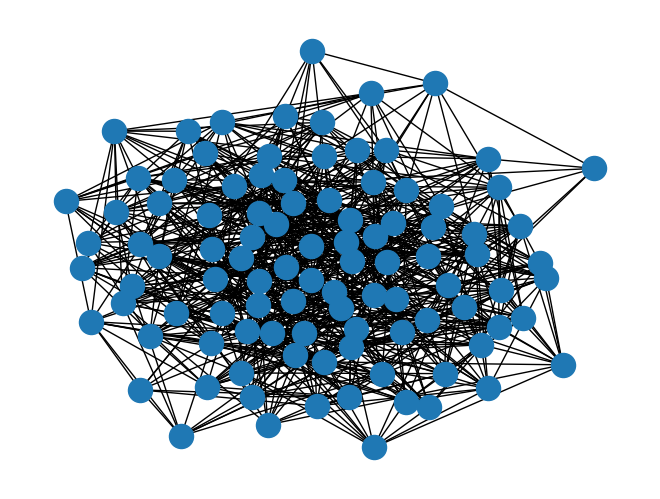

In [24]:
G = gnp_random_graph(100, 0.15)
nx.draw(G)
print('Graph has', G.number_of_edges(), 'edges.')

Run the above cell a few times and note that the number of edges varies slightly among random graphs generated with the same parameters. This is because each pair of nodes has an independent chance of being an edge.

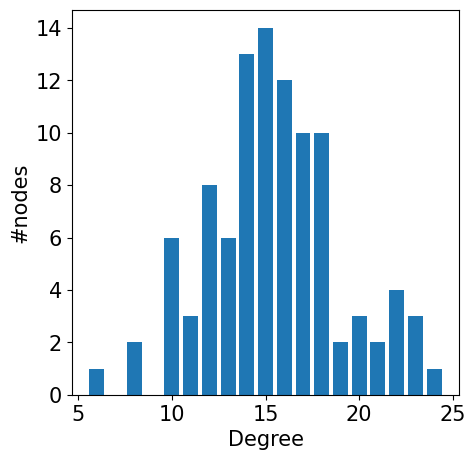

In [25]:
represent_degree_distribution(G)

### Erdös-Rényi random graph model

Instead of specifying the link probability $p$, we can also generate a graph of $N$ nodes with exactly $M$ edges by using `random.sample()` to choose M of the possible edges generated with `itertools.combinations()`:

In [28]:
def gnm_random_graph(N, M):
    G = nx.Graph()
    G.add_nodes_from(range(N))
    
    possible_edges = itertools.combinations(G.nodes(), 2)
    edges_to_add = random.sample(list(possible_edges), M)
    G.add_edges_from(edges_to_add)
    
    return G

Graph has 500 edges.


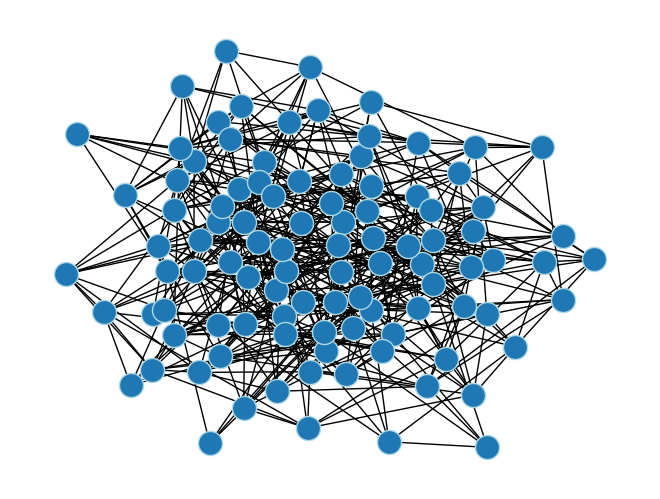

In [29]:
G = gnm_random_graph(100, 500)
pos = nx.spring_layout(G)
nx.draw(G,edgecolors='lightblue')
print('Graph has', G.number_of_edges(), 'edges.')
#plt.savefig('graph_er.jpg')

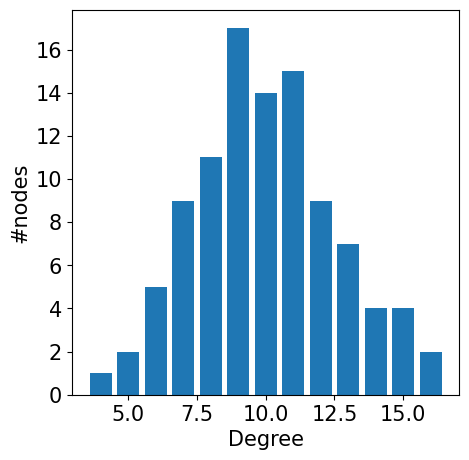

In [30]:
represent_degree_distribution(G)

### NetworkX functions

NetworkX has a function for the $G_{n,p}$ random graph specifying number of nodes $N$ and link probability $p$:  [gnp_random_graph()](https://networkx.github.io/documentation/stable/reference/generated/networkx.generators.random_graphs.gnp_random_graph.html).

In addition, NetworkX provides [gnm_random_graph()](https://networkx.github.io/documentation/stable/reference/generated/networkx.generators.random_graphs.gnm_random_graph.html), which generates a $G_{n,m}$ graph, where we specify the number of nodes $N$ and the desired number of edges $M$.

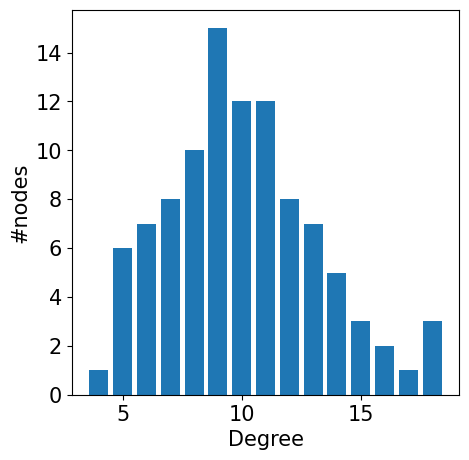

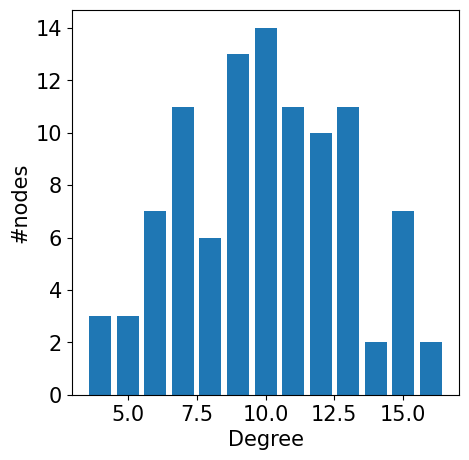

In [37]:
G=nx.gnp_random_graph(100,0.1)
represent_degree_distribution(G)
G=nx.gnm_random_graph(100,500)

represent_degree_distribution(G)

## 3. Small-World Model

The algorithm for generating a small-world network is as such:

1. Begin with a ring of $N$ nodes
2. Connect each node to its $k$ nearest neighbors (or $k-1$ if k is odd).
3. For each edge $(u, v)$, with probability $p$, replace edge $(u, v)$ with $(u, w)$ where $w$ is not a neighbor of $u$.

We'll do these step-by-step first, and combine them into a function last.

### Create a ring of N nodes

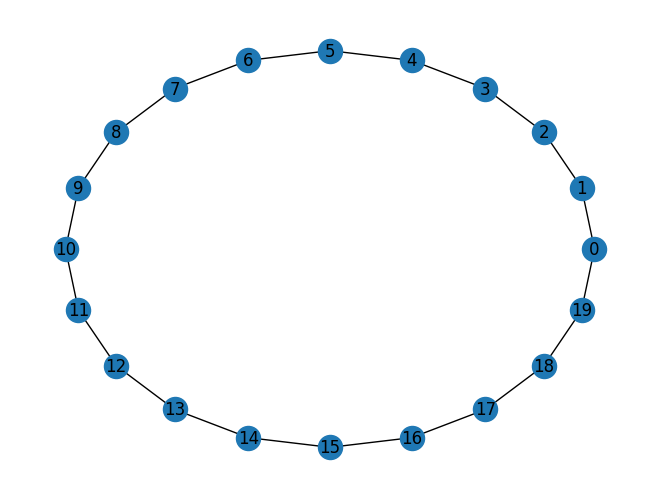

In [38]:
N = 20
G = nx.cycle_graph(N)
nx.draw_circular(G, with_labels=True)

### Connect each node to its $k$ nearest neighbors

We'll use modular arithmetic in order to do this. As an example of why, let's say $k$ is 4. So for node $n$, we want to add edges to $n$'s 4 nearest neighbors: $n-1, n+1, n-2,$ and $n+2.$ Since our nodes are in a circle, these can "wrap around", *e.g.* the 4 nearest neighbors of node 0 are N-1, 1, N-2, and 2.

Note the use of integer division (//) below. Integer division throws away the fractional part of division, e.g.

    5 // 2 = 2

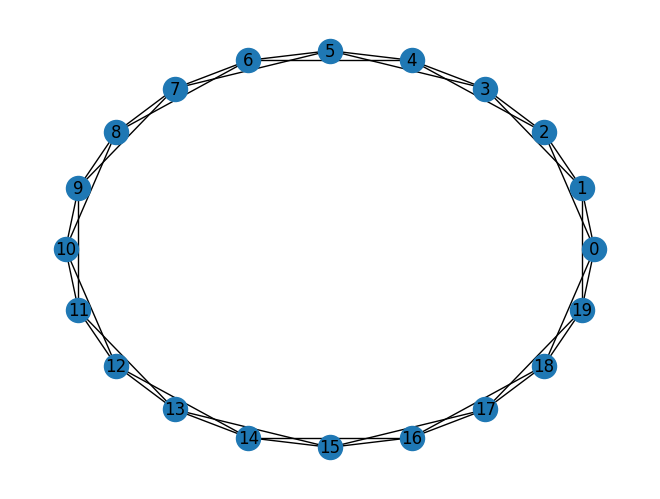

In [39]:
k = 4

for n in G.nodes():
    for i in range(1, k // 2 + 1):
        left  = (n-i) % N
        right = (n+i) % N 
        G.add_edge(n, left)
        G.add_edge(n, right)

nx.draw_circular(G, with_labels=True)

### Rewire some edges

> For each edge $(u, v)$, with probability $p$, replace edge $(u, v)$ with (u, w) where $w$ is not a neighbor of $u$.

For this step, we make use of set arithmetic in order to generate a list of nodes that are not neighbors of $u$, and `random.choice` to select $w$ at random from that set of "not neighbors."

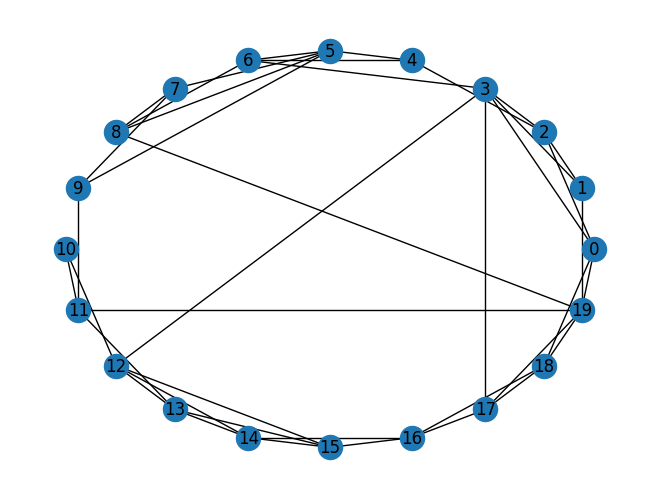

In [40]:
p = 0.2

for u, v in list(G.edges()):
    if random.random() < p:
        not_neighbors = set(G.nodes()) - set(G.neighbors(u))
        w=u
        while w==u:
            w = random.choice(list(not_neighbors))
        G.remove_edge(u, v)
        G.add_edge(u, w)

nx.draw_circular(G, with_labels=True)

### Watts-Strogatz Small-World Model

We can put this together to write a basic function for the small-world model:

In [41]:
def watts_strogatz_graph(N, k, p):
    # 1. Create a ring of N nodes
    G = nx.cycle_graph(N)

    # 2. Connect each node n to k nearest neighbors
    #    [n-(k//2), ... , n-1, n+1, ... , n+(k//2)]
    for n in G.nodes():
        for i in range(1, k // 2 + 1):
            left  = (n-i) % N
            right = (n+i) % N 
            G.add_edge(n, left)
            G.add_edge(n, right)
    
    # 3. Rewire edges with probability p
    for u, v in list(G.edges()):
        if random.random() < p:
            not_neighbors = set(G.nodes()) - set(G.neighbors(u)) - {u}
            w = random.choice(list(not_neighbors))
            G.remove_edge(u, v)
            G.add_edge(u, w)

    return G

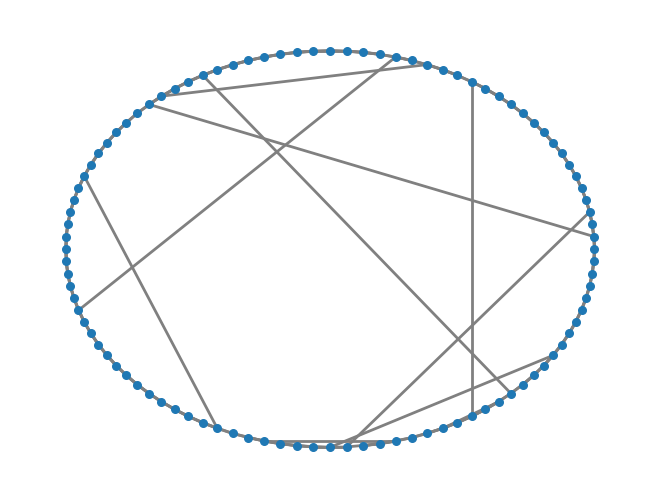

In [59]:
G = watts_strogatz_graph(100, 4, 0.05)
nx.draw_circular(G, with_labels=False,node_size=30,width=2,edge_color='gray')

In [60]:
# Average distance
print('Average shortest path length:',nx.average_shortest_path_length(G))
print('Average clustering coefficient',nx.average_clustering(G))
print('Transitivity',nx.transitivity(G))


Average shortest path length: 5.874141414141414
Average clustering coefficient 0.43700000000000006
Transitivity 0.42716857610474634


Let us check how the average shortest path length and clustering depend on the rewiring probabilty

In [61]:
pvalues=np.logspace(-4,0,51)
shortest_path_length_values=[]
clustering_values=[]
pvalues_included=[]
for p in pvalues:
    try:
        G = watts_strogatz_graph(1000, 4,p)
        shortest_path_length_values.append(nx.average_shortest_path_length(G))
        pvalues_included.append(p)
        clustering_values.append(nx.average_clustering(G))
        print('Rewiring probability',p)
    except:
        continue

Rewiring probability 0.0001
Rewiring probability 0.00012022644346174131
Rewiring probability 0.0001445439770745928
Rewiring probability 0.00017378008287493763
Rewiring probability 0.00020892961308540387
Rewiring probability 0.00025118864315095795
Rewiring probability 0.0003019951720402016
Rewiring probability 0.0003630780547701014
Rewiring probability 0.0004365158322401661
Rewiring probability 0.0005248074602497723
Rewiring probability 0.000630957344480193
Rewiring probability 0.0007585775750291835
Rewiring probability 0.0009120108393559096
Rewiring probability 0.0010964781961431851
Rewiring probability 0.0013182567385564075
Rewiring probability 0.001584893192461114
Rewiring probability 0.0019054607179632482
Rewiring probability 0.0022908676527677745
Rewiring probability 0.002754228703338166
Rewiring probability 0.003311311214825911
Rewiring probability 0.003981071705534973
Rewiring probability 0.00478630092322638
Rewiring probability 0.005754399373371567
Rewiring probability 0.0069183

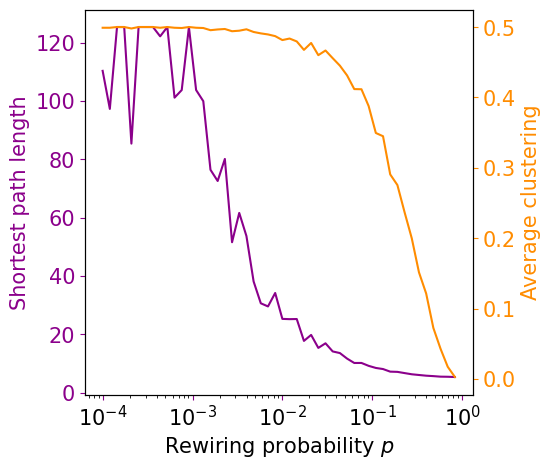

In [62]:
fig,ax=plt.subplots(1,1,figsize=(5,5),sharex=True)

color='darkmagenta'
ax.plot(pvalues_included,shortest_path_length_values,color=color)
ax.set_xscale('log')
ax.set_ylabel('Shortest path length',fontsize=15,color=color)
ax.set_xlabel('Rewiring probability $p$',fontsize=15)
ax.tick_params(which='major',axis='both',labelsize=15,color=color)
ax.tick_params(which='major',axis='y',labelsize=15,labelcolor=color)

color='darkorange'
axtwin=ax.twinx()
axtwin.plot(pvalues_included,clustering_values,color=color)
axtwin.set_ylabel('Average clustering',fontsize=15,color=color)
axtwin.tick_params(which='major',axis='both',labelsize=15,color=color)
axtwin.tick_params(which='major',axis='y',labelsize=15,labelcolor=color)



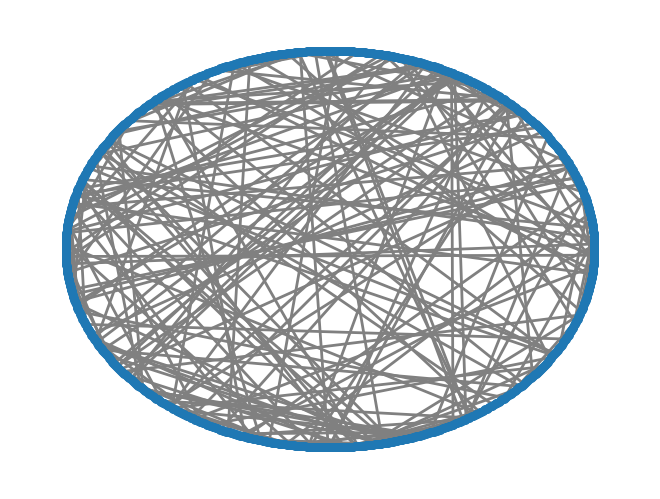

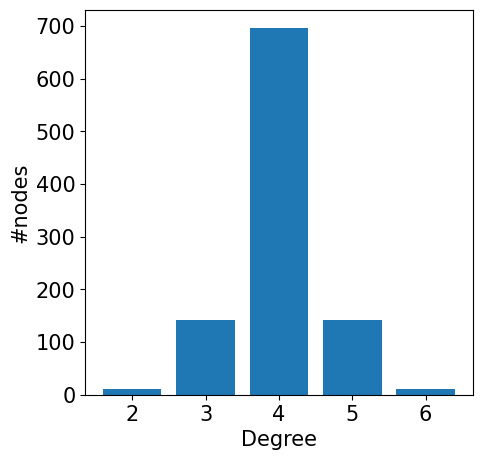

In [66]:
G = watts_strogatz_graph(1000, 4, 0.1)
nx.draw_circular(G, with_labels=False,node_size=30,width=2,edge_color='gray')
represent_degree_distribution(G)

### NetworkX function

NetworkX has a function for this model: [watts_strogatz_graph()](https://networkx.github.io/documentation/stable/reference/generated/networkx.generators.random_graphs.watts_strogatz_graph.html).

## 4. Preferential Attachment Model

The Barabási-Albert preferential attachment model has two parameters: the number of nodes $N$, and the number of links added at each step $m$. Given these parameters, the algorithm is as follows:

1. Start with a clique of $m + 1$ nodes.
2. Select $m$ different nodes at random, weighted by their degree.
3. Add a new node $i$ and link it with the $m$ nodes from the previous step.
4. Repeat 2-3 until there are N nodes in the graph.

The code for this is thus straightforward, with one possible exception: for step 3, we need to generate a *degree sequence* to weight the random selection. If we have a graph `G`, we can generate such a degree sequence with a list comprehension as follows:

In [67]:
def barabasi_albert_graph(N, m):
    # 1. Start with a clique of m+1 nodes
    G = nx.complete_graph(m + 1)
    for i in range(G.number_of_nodes(), N):
        # 2. Select m different nodes at random, weighted by their degree.
        new_neighbors = []
        possible_neighbors = list(G.nodes())
        for _ in range(m):
            degrees = [G.degree(n) for n in possible_neighbors]
            
            j = random.choices(possible_neighbors, degrees)[0]
            new_neighbors.append(j)
            possible_neighbors.remove(j)
        
        # 3. Add a new node i and link it with the m nodes from the previous step.
        for j in new_neighbors:
            G.add_edge(i, j)

    return G

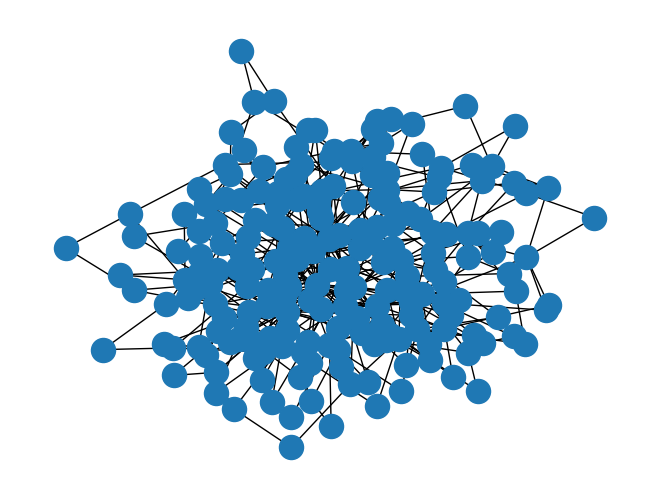

In [68]:
G = barabasi_albert_graph(200, 2)
nx.draw(G)

One might wonder why, in the previous code for `preferential_attachment_graph`, we didn't just write step 2 as

    new_neighbors = random.choices(G.nodes, degrees, k=m)
    
The issue here is that when one specifies $k > 1$ for `random.choices`, the selection is made with replacement, *i.e.* the same node can be selected from the list multiple times. The more complicated code is necessary so that we choose $m$ different nodes to join with node $i$.

### NetworkX function

As with all of these graph models, NetworkX has a function to generate a BA model: [barabasi_albert_graph()](https://networkx.github.io/documentation/stable/reference/generated/networkx.generators.random_graphs.barabasi_albert_graph.html).

In [69]:
G_BA = nx.barabasi_albert_graph(10000, 3)
#nx.draw(G_BA,edgecolors='lightblue')

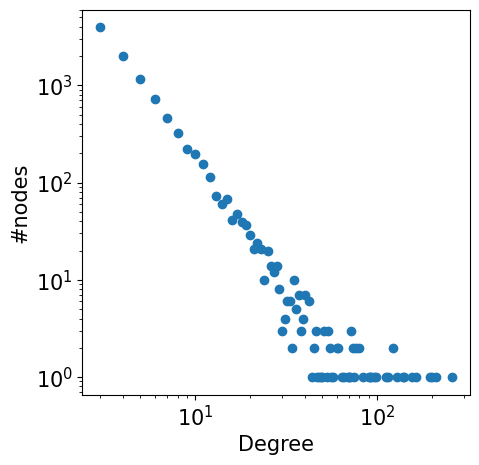

In [70]:
represent_degree_distribution(G_BA,scale='log',rep='scatter')

/var/folders/y_/1f6tyxqn3hd98mt_8yc4vp0r0000gn/T/ipykernel_9339/1870299794.py:20: RuntimeWarning: divide by zero encountered in log
  log_ccdf_fit=np.log(ccdf)[:-1]


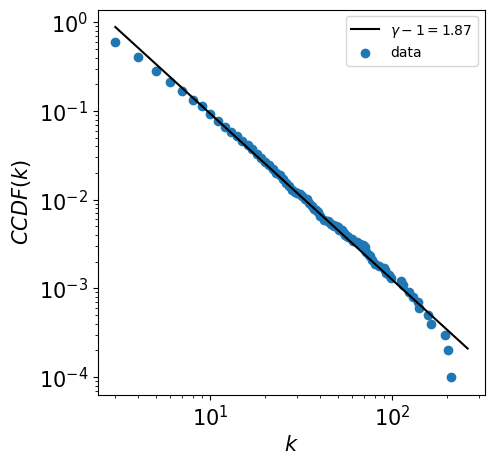

In [71]:
fit_CCDF(G_BA)